In [2]:
import pandas as pd

file_path = r"E:\Projects\Data Science\IMS\IMS\3rd_test\4th_test\txt\2004.03.04.09.27.46"

df = pd.read_csv(file_path, sep='\t', header=None)

print(df.shape)
df.head()

(20480, 4)


,0,1,2,3
0,0.034,0.264,0.039,-0.046
1,0.103,0.083,-0.061,-0.012
2,0.095,-0.039,-0.007,0.039
3,0.000,0.110,0.022,-0.002
4,0.005,0.154,-0.127,-0.020


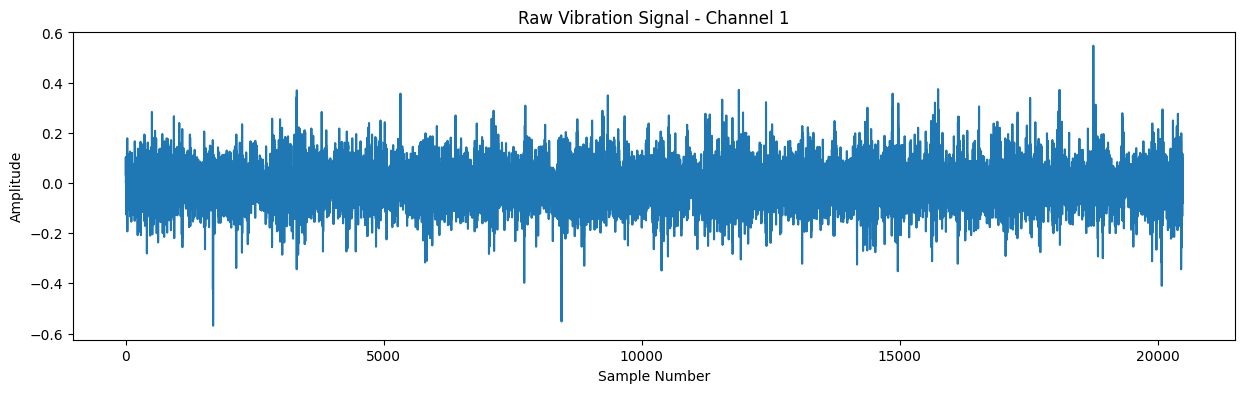

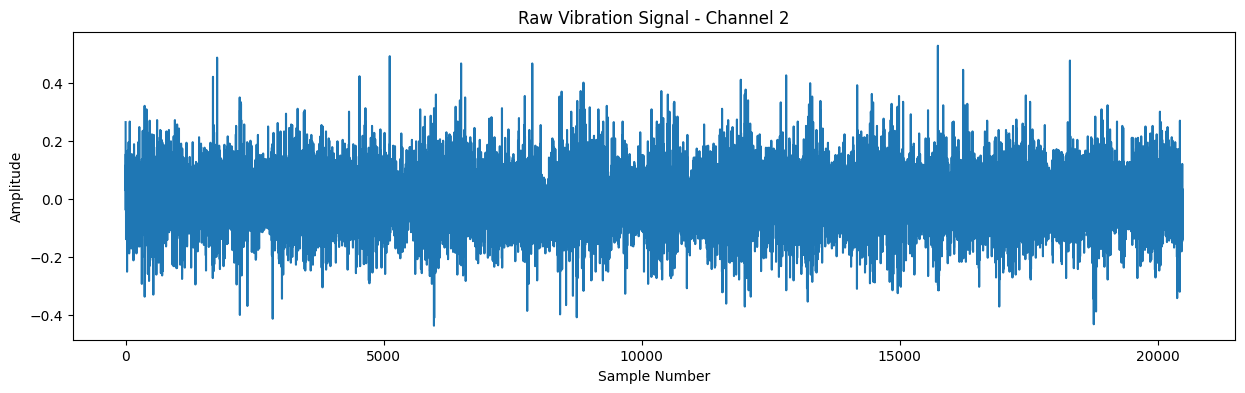

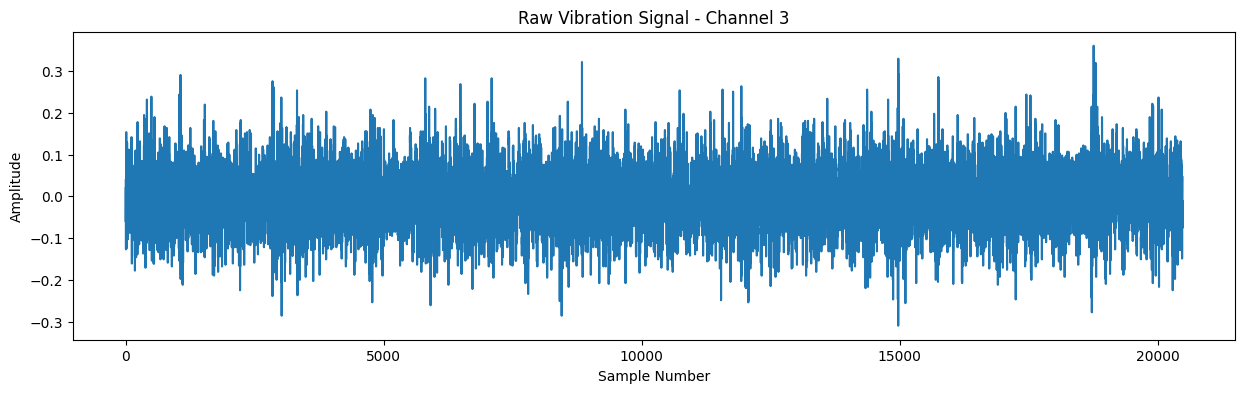

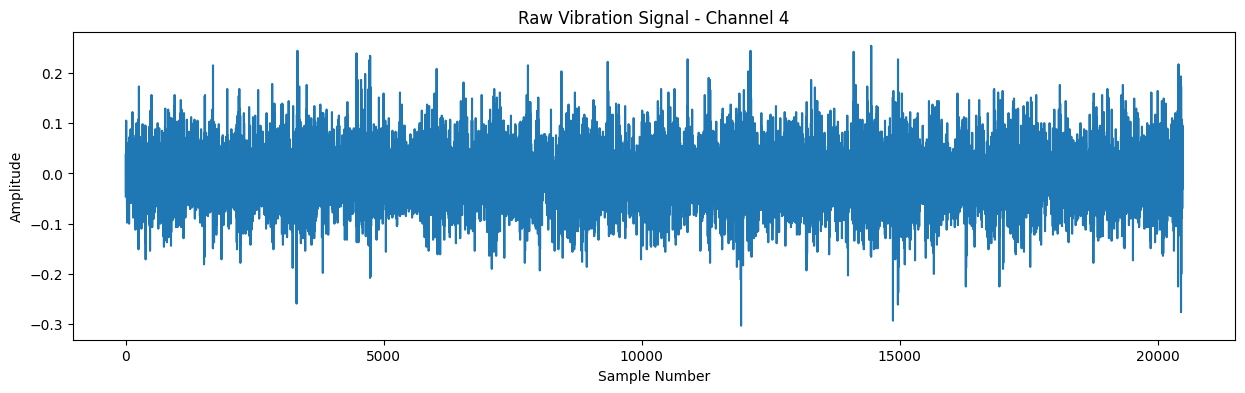

In [3]:
import matplotlib.pyplot as plt


for i in df:
    plt.figure(figsize=(15,4))
    plt.plot(df[i])
    plt.title(f"Raw Vibration Signal - Channel {i+1}")
    plt.xlabel("Sample Number")
    plt.ylabel("Amplitude")
    plt.show()

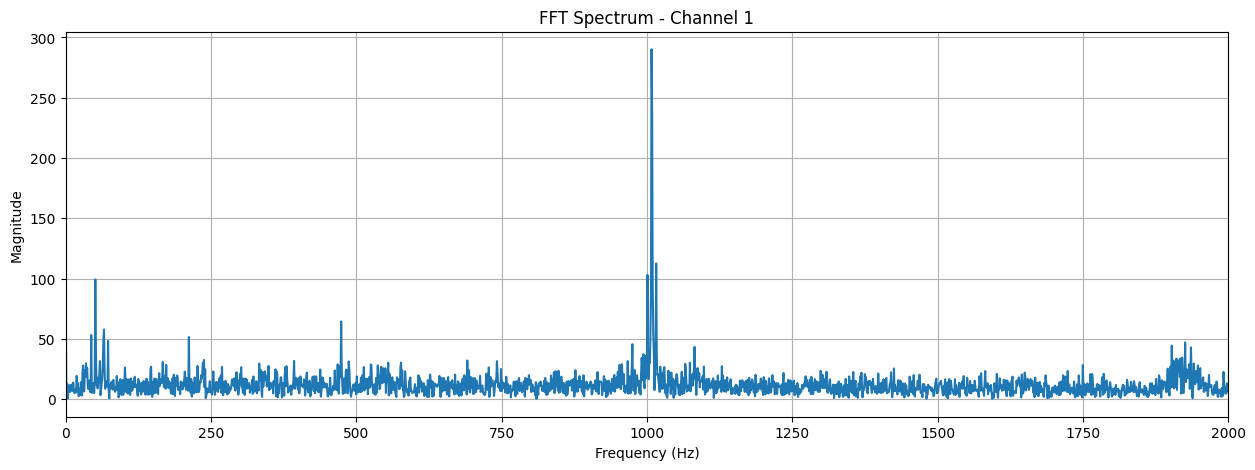

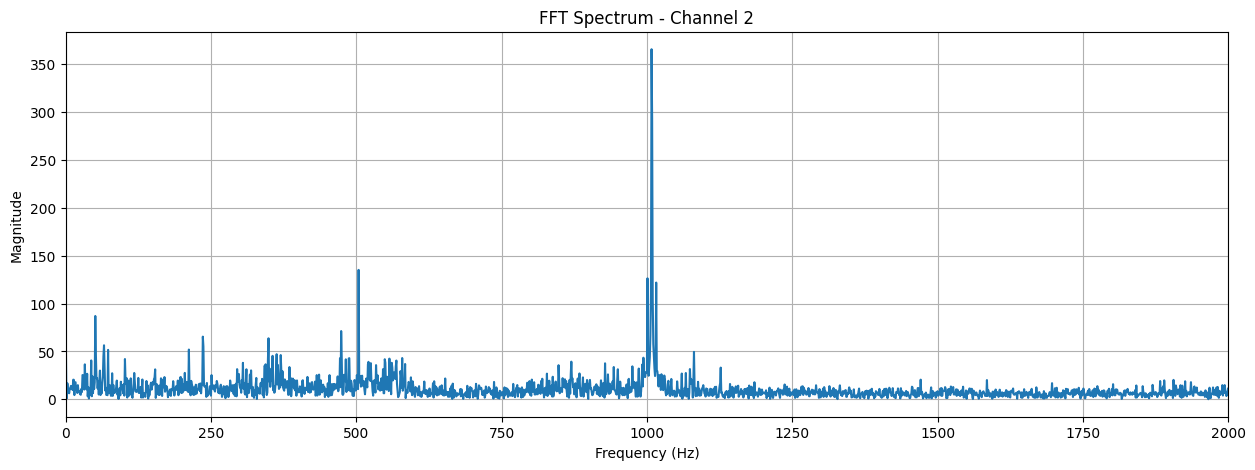

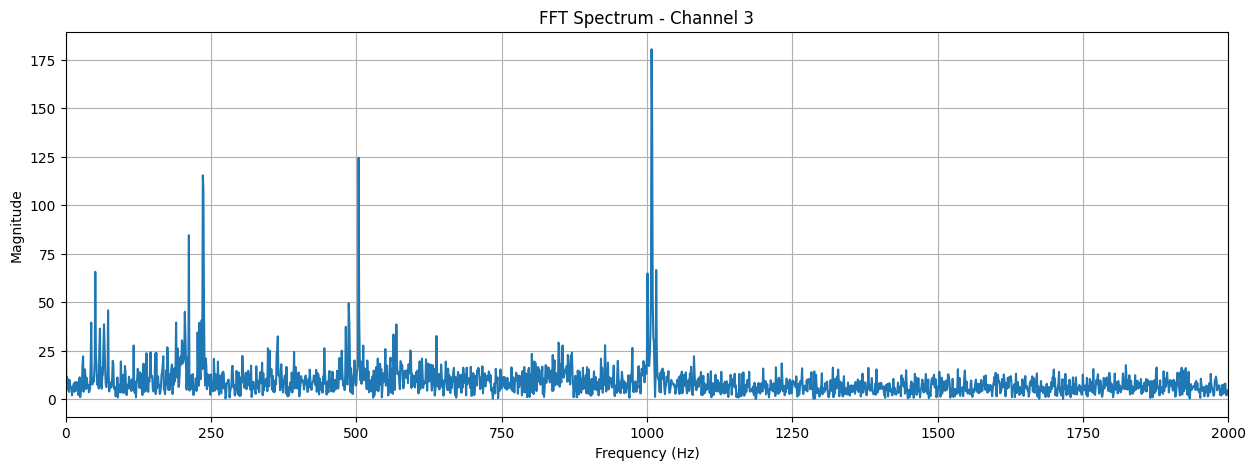

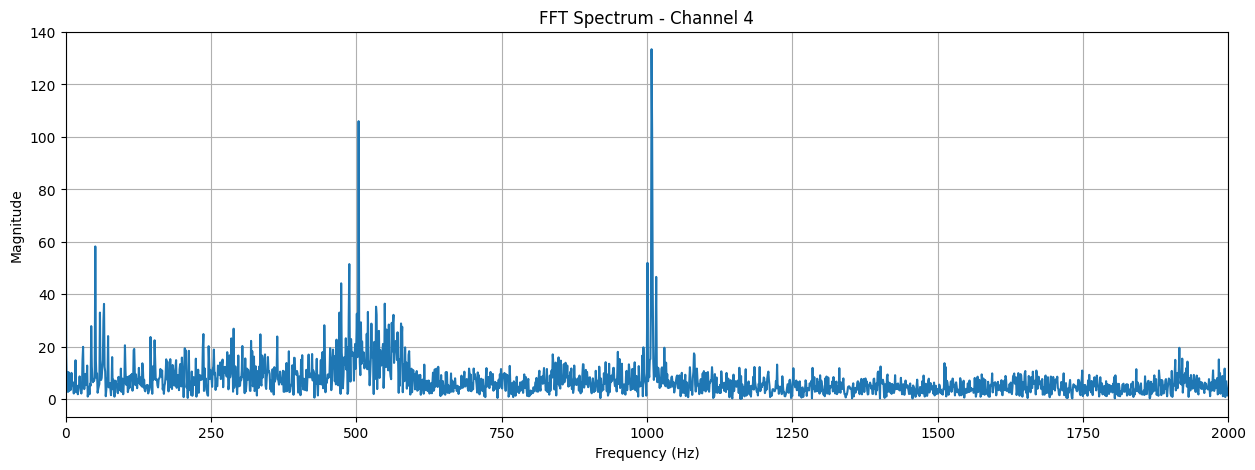

In [4]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

for i in df.columns:
    signal = df[i].values

    N = len(signal)
    Fs = 20480

    fft_values = fft(signal)

    frequencies = fftfreq(N, 1/Fs)

    positive_freqs = frequencies[:N//2]
    magnitudes = np.abs(fft_values[:N//2])

    plt.figure(figsize=(15,5))
    plt.plot(positive_freqs, magnitudes)

    plt.title(f"FFT Spectrum - Channel {i+1}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

    plt.xlim(0, 2000)

    plt.grid(True)

    plt.show()

In [5]:
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis

def extract_features(signal, fs=20480):

    # Time-domain features
    rms = np.sqrt(np.mean(signal**2))
    std = np.std(signal)
    variance = np.var(signal)
    kurt = kurtosis(signal)

    # FFT
    N = len(signal)

    fft_values = fft(signal)
    frequencies = fftfreq(N, 1/fs)

    positive_freqs = frequencies[:N//2]
    magnitudes = np.abs(fft_values[:N//2])

    # Frequency-domain features
    peak_idx = np.argmax(magnitudes)

    peak_freq = positive_freqs[peak_idx]
    peak_mag = magnitudes[peak_idx]

    return {
        "RMS": rms,
        "STD": std,
        "Variance": variance,
        "Kurtosis": kurt,
        "PeakFreq": peak_freq,
        "PeakMagnitude": peak_mag
    }


#checking for 20 files

In [6]:
def aggregate_features(channel_features):

    return {
        "RMS_mean": np.mean([f["RMS"] for f in channel_features]),

        "RMS_max": np.max([f["RMS"] for f in channel_features]),

        "Variance_mean": np.mean([f["Variance"] for f in channel_features]),

        "Kurtosis_mean": np.mean([f["Kurtosis"] for f in channel_features]),

        "PeakFreq_mean": np.mean([f["PeakFreq"] for f in channel_features]),

        "PeakMag_mean": np.mean([f["PeakMagnitude"] for f in channel_features]),

        "PeakMag_max": np.max([f["PeakMagnitude"] for f in channel_features])
    }

channel_features = []

for channel in range(4):

    signal = df[channel].values

    features = extract_features(signal)

    channel_features.append(features)

machine_features = aggregate_features(channel_features)

pd.DataFrame([machine_features])

,RMS_mean,RMS_max,Variance_mean,Kurtosis_mean,PeakFreq_mean,PeakMag_mean,PeakMag_max
0,0.074593,0.09672,0.00578,0.805369,1008.0,242.430729,365.727217


#checking for 100 files

In [7]:
import os
folder_path = r"E:\Projects\Data Science\IMS\IMS\3rd_test\4th_test\txt"

all_machine_features = []

files = sorted(os.listdir(folder_path))

for file in files:

    file_path = os.path.join(folder_path, file)

    df = pd.read_csv(
        file_path,
        sep="\t",
        header=None
    )

    channel_features = []

    for channel in range(4):

        signal = df[channel].values

        features = extract_features(signal)

        channel_features.append(features)

    machine_features = aggregate_features(channel_features)

    machine_features["File"] = file

    all_machine_features.append(machine_features)

feature_df = pd.DataFrame(all_machine_features)

feature_df

,RMS_mean,RMS_max,Variance_mean,Kurtosis_mean,PeakFreq_mean,PeakMag_mean,PeakMag_max,File
0,0.074593,0.096720,0.005780,0.805369,1008.00,242.430729,365.727217,2004.03.04.09.27.46
1,0.072580,0.092008,0.005440,0.643772,1009.00,278.600209,428.033686,2004.03.04.09.32.46
2,0.073784,0.093430,0.005660,0.629781,816.00,298.352749,435.281739,2004.03.04.09.42.46
3,0.074342,0.092803,0.005718,0.550658,816.25,246.487345,361.279315,2004.03.04.09.52.46
4,0.073344,0.092829,0.005580,0.436923,1010.00,261.657337,394.819261,2004.03.04.10.02.46
...,...,...,...,...,...,...,...,...
6319,0.283166,0.495363,0.096379,4.237111,3965.00,769.161141,984.434913,2004.04.18.02.02.55
6320,0.263305,0.454466,0.083202,1.361531,1657.75,774.103201,1049.985802,2004.04.18.02.12.55
6321,0.316937,0.590047,0.126143,3.253640,2243.00,1132.527283,1635.128000,2004.04.18.02.22.55
6322,0.363155,0.758765,0.185655,2.081531,1420.50,1071.616863,1834.406136,2004.04.18.02.32.55


#Plotting

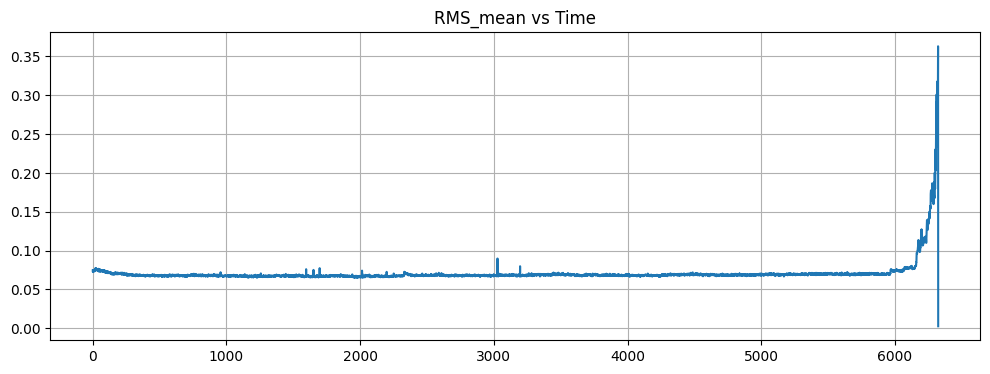

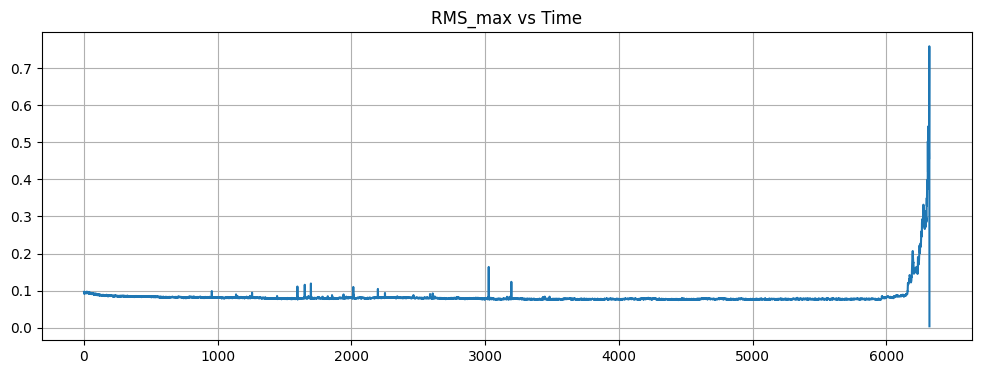

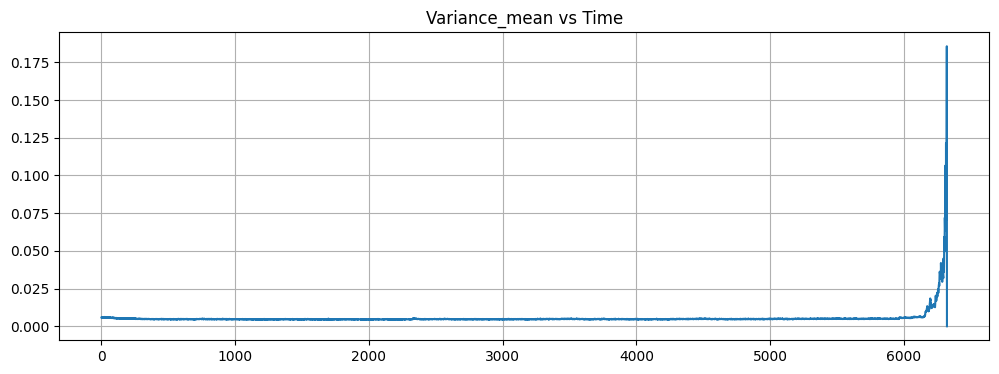

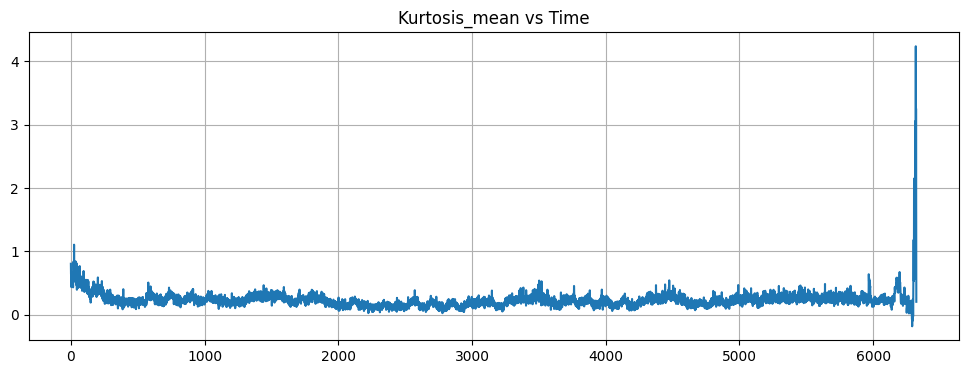

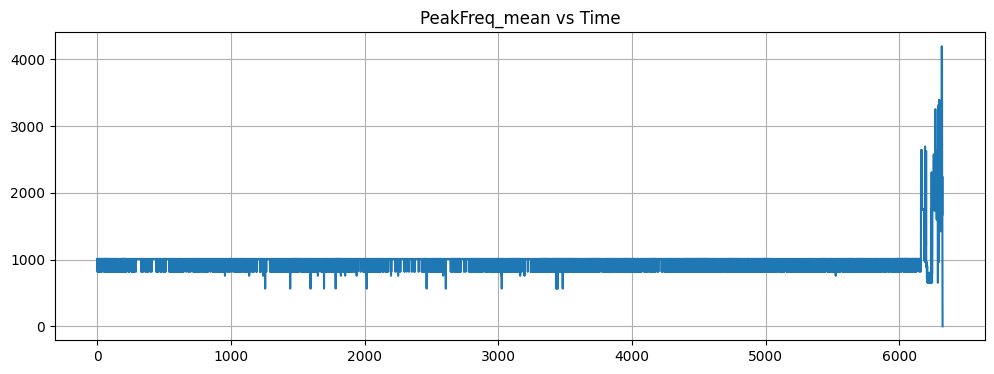

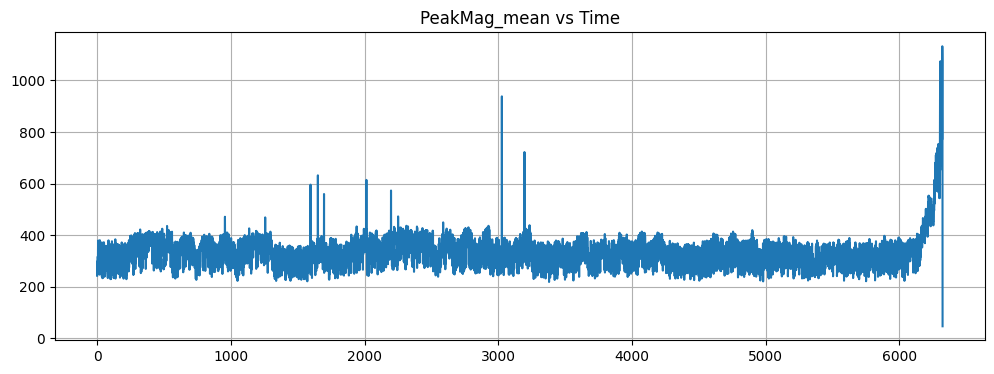

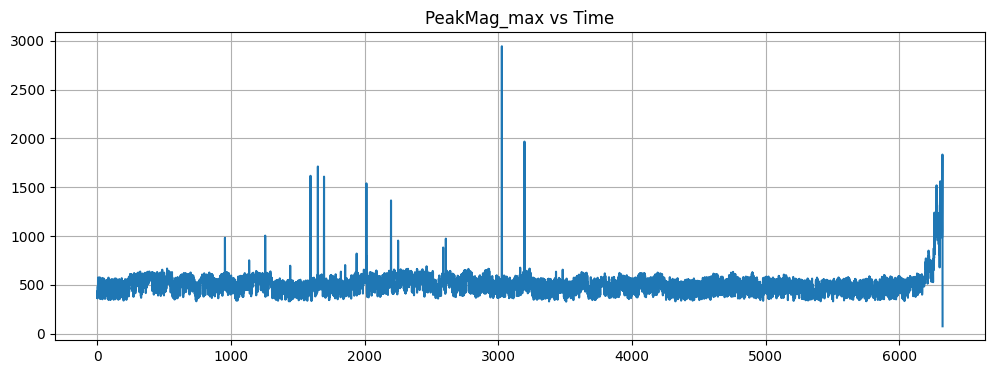

In [8]:

for feature in feature_df:
    if feature == "File":
        break
    plt.figure(figsize=(12,4))
    plt.plot(feature_df[feature])
    plt.title(f"{feature} vs Time")
    plt.grid()
    plt.show()

downloading the feature extracted dataset

In [9]:
feature_df.to_csv(
    "bearing_features.csv",
    index=False
)

Standardising

In [10]:
feature_df = pd.read_csv(
    "bearing_features.csv"
)

health_features = [
    "RMS_max",
    "Variance_mean",
    "Kurtosis_mean",
    "PeakMag_max"
]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = scaler.fit_transform(
    feature_df[health_features]
)

In [11]:
import joblib
feature_df["DegradationScore"] = normalized.mean(axis=1)
feature_df["HealthScore"] = (
    100 * (1 - feature_df["DegradationScore"])
).round(2)
feature_df = feature_df.iloc[:-1]

joblib.dump(
    scaler,
    "health_scaler.pkl"
)

['health_scaler.pkl']

#removed the last row as it shows healthy indication

In [12]:
feature_df

,RMS_mean,RMS_max,Variance_mean,Kurtosis_mean,PeakFreq_mean,PeakMag_mean,PeakMag_max,File,DegradationScore,HealthScore
0,0.074593,0.096720,0.005780,0.805369,1008.00,242.430729,365.727217,2004.03.04.09.27.46,0.119650,88.03
1,0.072580,0.092008,0.005440,0.643772,1009.00,278.600209,428.033686,2004.03.04.09.32.46,0.113916,88.61
2,0.073784,0.093430,0.005660,0.629781,816.00,298.352749,435.281739,2004.03.04.09.42.46,0.114525,88.55
3,0.074342,0.092803,0.005718,0.550658,816.25,246.487345,361.279315,2004.03.04.09.52.46,0.103469,89.65
4,0.073344,0.092829,0.005580,0.436923,1010.00,261.657337,394.819261,2004.03.04.10.02.46,0.099779,90.02
...,...,...,...,...,...,...,...,...,...,...
6318,0.263484,0.431816,0.080992,0.567536,4033.00,984.451928,1350.981834,2004.04.18.01.52.55,0.404316,59.57
6319,0.283166,0.495363,0.096379,4.237111,3965.00,769.161141,984.434913,2004.04.18.02.02.55,0.621786,37.82
6320,0.263305,0.454466,0.083202,1.361531,1657.75,774.103201,1049.985802,2004.04.18.02.12.55,0.433493,56.65
6321,0.316937,0.590047,0.126143,3.253640,2243.00,1132.527283,1635.128000,2004.04.18.02.22.55,0.694279,30.57


In [13]:
from sklearn.preprocessing import StandardScaler

features = [
    "RMS_mean",
    "RMS_max",
    "Variance_mean",
    "Kurtosis_mean",
    "PeakFreq_mean",
    "PeakMag_mean",
    "PeakMag_max"
]

X = feature_df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

iso.fit(X_scaled)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


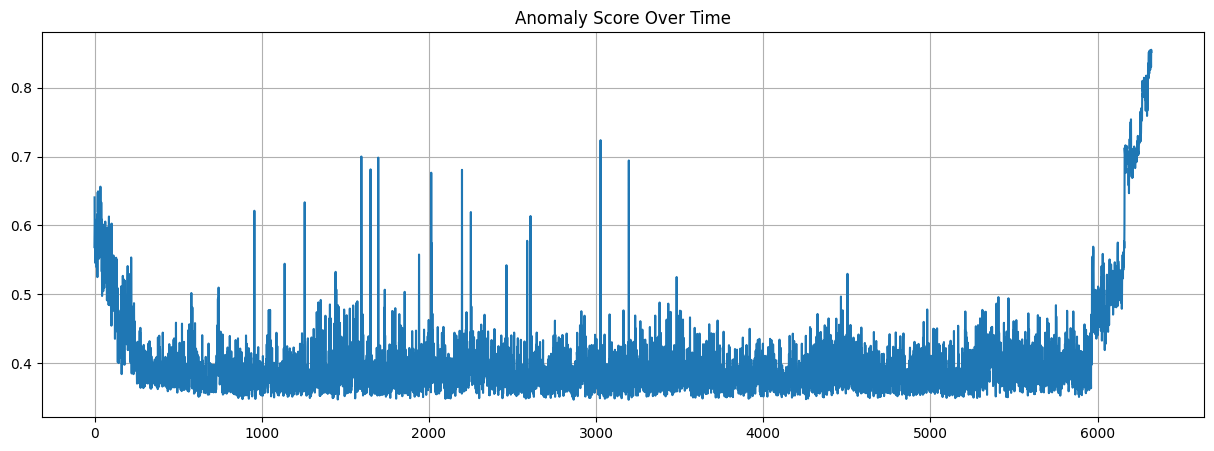

In [14]:
feature_df["Anomaly"] = iso.predict(X_scaled)

feature_df["AnomalyScore"] = (
    -iso.score_samples(X_scaled)
)

plt.figure(figsize=(15,5))

plt.plot(feature_df["AnomalyScore"])

plt.title("Anomaly Score Over Time")

plt.grid()

plt.show()

In [15]:
feature_df


,RMS_mean,RMS_max,Variance_mean,Kurtosis_mean,PeakFreq_mean,PeakMag_mean,PeakMag_max,File,DegradationScore,HealthScore,Anomaly,AnomalyScore
0,0.074593,0.096720,0.005780,0.805369,1008.00,242.430729,365.727217,2004.03.04.09.27.46,0.119650,88.03,1,0.640737
1,0.072580,0.092008,0.005440,0.643772,1009.00,278.600209,428.033686,2004.03.04.09.32.46,0.113916,88.61,1,0.567173
2,0.073784,0.093430,0.005660,0.629781,816.00,298.352749,435.281739,2004.03.04.09.42.46,0.114525,88.55,1,0.594449
3,0.074342,0.092803,0.005718,0.550658,816.25,246.487345,361.279315,2004.03.04.09.52.46,0.103469,89.65,1,0.608172
4,0.073344,0.092829,0.005580,0.436923,1010.00,261.657337,394.819261,2004.03.04.10.02.46,0.099779,90.02,1,0.545662
...,...,...,...,...,...,...,...,...,...,...,...,...
6318,0.263484,0.431816,0.080992,0.567536,4033.00,984.451928,1350.981834,2004.04.18.01.52.55,0.404316,59.57,-1,0.849830
6319,0.283166,0.495363,0.096379,4.237111,3965.00,769.161141,984.434913,2004.04.18.02.02.55,0.621786,37.82,-1,0.847246
6320,0.263305,0.454466,0.083202,1.361531,1657.75,774.103201,1049.985802,2004.04.18.02.12.55,0.433493,56.65,-1,0.830223
6321,0.316937,0.590047,0.126143,3.253640,2243.00,1132.527283,1635.128000,2004.04.18.02.22.55,0.694279,30.57,-1,0.855310


for chatgpt

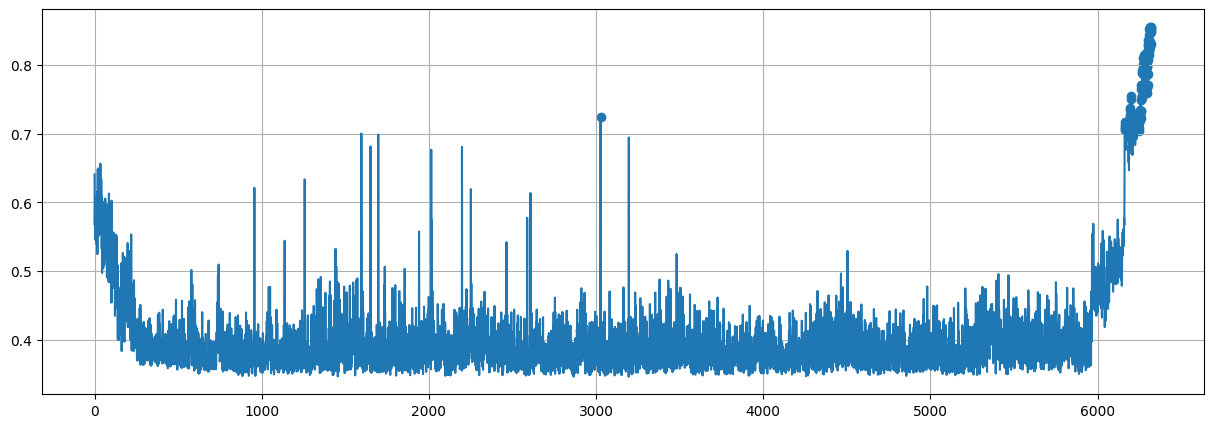

In [16]:
feature_df["Anomaly"].value_counts()
plt.figure(figsize=(15,5))

plt.plot(feature_df["AnomalyScore"])

anomalies = feature_df[
    feature_df["Anomaly"] == -1
]

plt.scatter(
    anomalies.index,
    anomalies["AnomalyScore"]
)

plt.grid()
plt.show()

Saving the final dataset

In [19]:
feature_df.to_csv(
    "sentinel_bearing_features.csv",
    index=False
)

Saving the ML models iso and scalar

In [20]:
import joblib
joblib.dump(iso, "iso_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

verification 

In [23]:
import joblib

loaded_scaler = joblib.load("scaler.pkl")
loaded_model = joblib.load("iso_model.pkl")
loaded_health_scaler = joblib.load("health_scaler.pkl")

print(type(loaded_scaler))
print(type(loaded_model))
print(type(loaded_health_scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'sklearn.ensemble._iforest.IsolationForest'>
<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [ ]:
health_features

['RMS_max', 'Variance_mean', 'Kurtosis_mean', 'PeakMag_max']

: 